# Sensor Digital
---

In [2]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 

## Generacion de Datos y Extraccion de Parametros

### Contexto
Vamos a usar NumPy para crear nuestra "realidad sintética" y Matplotlib para visualizar que, efectivamente, la naturaleza (y los motores sanos) siguen una Distribución Normal.

In [4]:
media_real = 80
std_real = 5
n_muestras = 1000 

# Generar datos sintéticos (Sanos)
np.random.seed(42)  # Para reproducibilidad
datos_sanos =np.random.normal(media_real,std_real,n_muestras)

#Inyeccion de datos anómalos (Enfermos)
anomalias =  np.array([110,115,108,45,40,120,35,112,118,42])
datos_totales = np.concatenate([datos_sanos,anomalias])

# Calculo de Parametros

mu_estimada = np.mean(datos_sanos)
sigma_estimada= np.std(datos_sanos)

print(f"-----Caracterizacion del Motor------")
print(f"Media aprendida (mu) :  {mu_estimada:.2f}°C") 
print(f"Desviacion estandar aprendida (sigma) : {sigma_estimada:.2f}°C")




 



-----Caracterizacion del Motor------
Media aprendida (mu) :  80.10°C
Desviacion estandar aprendida (sigma) : 4.89°C


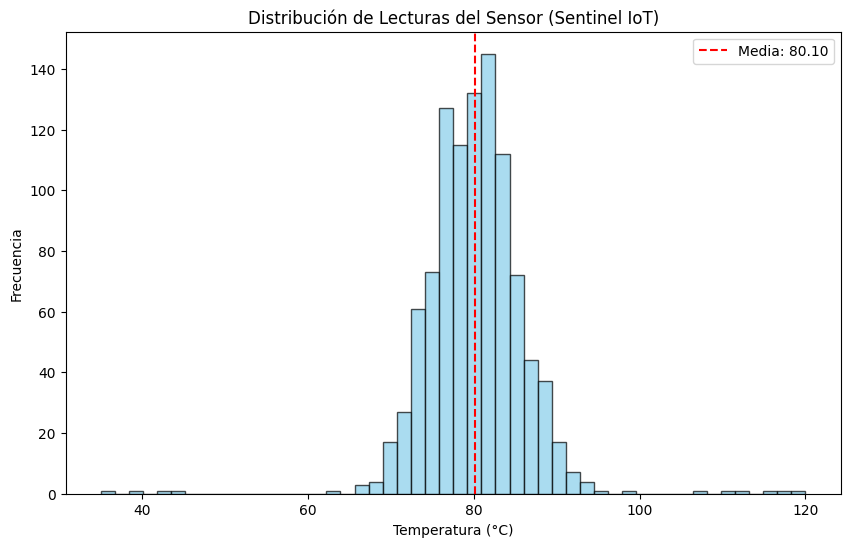

In [5]:
#Visualizacion de los datos
plt.figure(figsize=(10,6))
plt.hist(datos_totales, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribución de Lecturas del Sensor (Sentinel IoT)")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frecuencia")
plt.axvline(mu_estimada, color='red', linestyle='--', label=f'Media: {mu_estimada:.2f}')
plt.legend()
plt.show()

## Motor de deteccion Z-Score + PDF

In [8]:
from scipy.stats import norm


In [10]:
#Definirmos el umbral de alerta (Threshold)
# Z-Score = 3 , cubriendo el 99.7% de los datos normales
umbral_z = 3

#Calculamos los Z-Scores para cada lectura
z_scores = (datos_totales -mu_estimada) / sigma_estimada

#Identificamos las lecturas anómalas

indices_anomalias = np.abs(z_scores) > umbral_z
anomalias_detectadas = datos_totales[indices_anomalias]
datos_normales_detectados = datos_totales[~indices_anomalias]

#Preparar la curva PDF para el grafico

x_curva = np.linspace(mu_estimada -4*sigma_estimada ,mu_estimada +4 *sigma_estimada,100)
y_pdf =norm.pdf(x_curva,mu_estimada, sigma_estimada)


## Visualizacion de los Datos

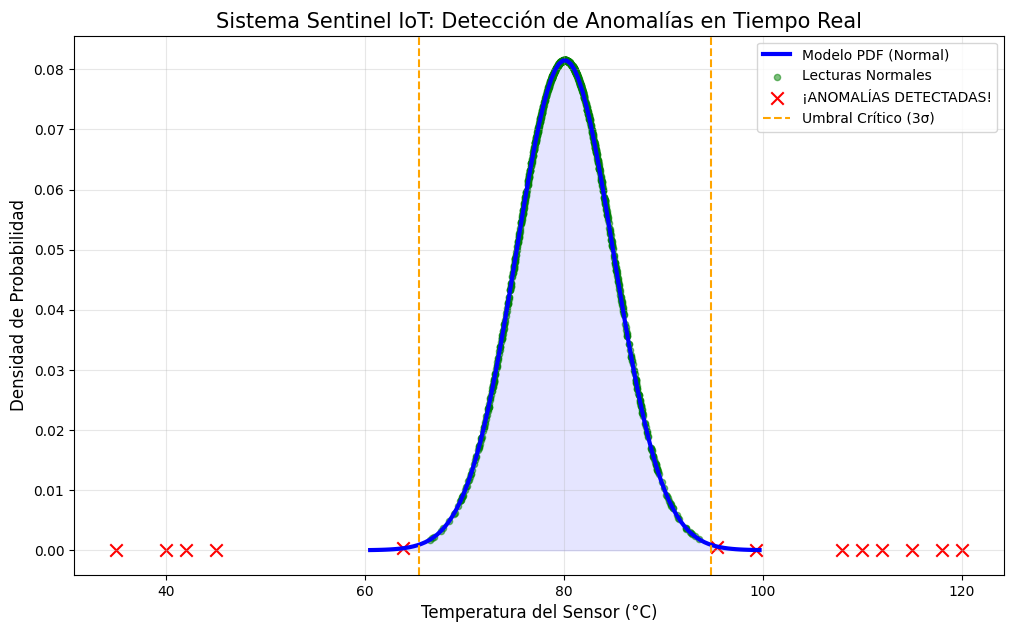

Resultado del Análisis:
- Total de lecturas procesadas: 1010
- Anomalías detectadas: 13
- Efectividad: 13 de 10 inyectadas.


In [11]:
plt.figure(figsize=(12, 7))

# Dibujar la PDF (La "firma" de salud del motor)
plt.plot(x_curva, y_pdf, 'b-', lw=3, label='Modelo PDF (Normal)')
plt.fill_between(x_curva, y_pdf, color='blue', alpha=0.1)

# Dibujar los datos detectados
plt.scatter(datos_normales_detectados, norm.pdf(datos_normales_detectados, mu_estimada, sigma_estimada), 
            color='green', s=20, alpha=0.5, label='Lecturas Normales')

plt.scatter(anomalias_detectadas, norm.pdf(anomalias_detectadas, mu_estimada, sigma_estimada), 
            color='red', s=80, marker='x', label='¡ANOMALÍAS DETECTADAS!')

# Configuración estética
plt.title("Sistema Sentinel IoT: Detección de Anomalías en Tiempo Real", fontsize=15)
plt.xlabel("Temperatura del Sensor (°C)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.axvline(mu_estimada + umbral_z*sigma_estimada, color='orange', linestyle='--', label='Umbral Crítico (3σ)')
plt.axvline(mu_estimada - umbral_z*sigma_estimada, color='orange', linestyle='--')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Resultado del Análisis:")
print(f"- Total de lecturas procesadas: {len(datos_totales)}")
print(f"- Anomalías detectadas: {len(anomalias_detectadas)}")
print(f"- Efectividad: {len(anomalias_detectadas)} de 10 inyectadas.")
